In [1]:
!pip install transformers
!pip install datasets
!pip install nltk
!pip install spacy


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import nltk
import spacy

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec
from wordcloud import WordCloud

from transformers import pipeline
from transformers import AutoTokenizer

from datasets import load_dataset

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [5]:
data = load_dataset('roneneldan/TinyStories')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [6]:
train_df = pd.DataFrame(data['train'])

train_df = train_df.sample(3000, random_state=42)

train_df = train_df[['text']]

train_df.head()

,text
1141313,"Once upon a time, there was a blue bird. The b..."
701730,Lily loved pandas. She had a big panda toy tha...
401788,"Once upon a time there was a big, old tree. Ev..."
377057,"Once upon a time, there was a bunny called Bob..."
1629778,"Once upon a time, there was a cold day. It was..."


In [7]:
train_df.shape

(3000, 1)

In [8]:
train_df.isnull().sum()

,0
text,0


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 1141313 to 596295
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3000 non-null   object
dtypes: object(1)
memory usage: 46.9+ KB


In [10]:
train_df['story_length'] = train_df['text'].apply(len)

train_df['story_length'].describe()

,story_length
count,3000.000000
mean,902.172333
std,407.620759
min,234.000000
25%,670.000000
50%,785.000000
75%,969.250000
max,4207.000000


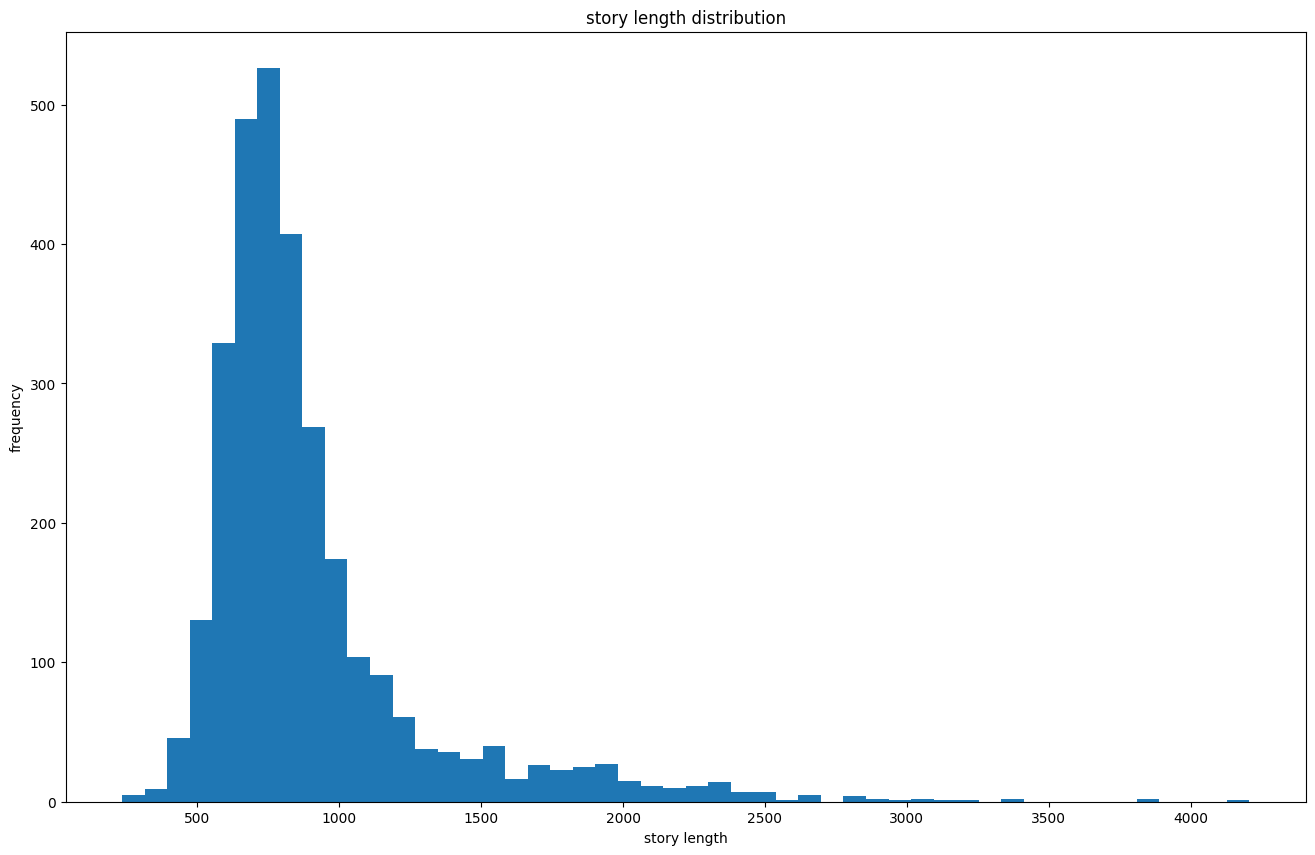

In [11]:
plt.figure(figsize=(16,10))
plt.hist(train_df['story_length'], bins=50)
plt.xlabel('story length')
plt.ylabel('frequency')
plt.title('story length distribution')
plt.show()

In [12]:
train_df['clean_text'] = train_df['text'].str.lower()

In [13]:
def clean_text(text):
  text = re.sub(r'[a-zA-Z\\s]','',text)
  return text

train_df['clean_text'] = train_df['clean_text'].apply(clean_text)

In [14]:
train_df['clean_text'] = train_df['clean_text'].apply(lambda x:re.sub(r'\\s+','',x))

In [15]:
train_df['tokens'] = train_df['clean_text'].apply(lambda x:x.split())

In [16]:
train_df['tokens'].head()

,tokens
1141313,"[,, ., ., ., ,, ., ., ., ,, .]"
701730,"[., ., ., ., ,, ., ,, ,, ,, ., ,, ., ,, ., ,, ..."
401788,"[,, ., ., ,, 3, ,, ., ., ,, ,, ., ,, ., ,, ., ..."
377057,"[,, ., ., ,, ., ., ,, "", ', !"", ., ,, ', ., .,..."
1629778,"[,, ., ., ., ., ., ., ., ., ., !, ., ,, ., ,, ..."


In [17]:
stopwords = set(stopwords.words('english'))

def remove_stopwords(tokens):
  return[word for word in tokens if word not in stopwords]

train_df['filtered_tokens'] = train_df['tokens'].apply(remove_stopwords)

In [18]:
stemmer = PorterStemmer()

def stem_words(tokens):

    return [stemmer.stem(word) for word in tokens]

train_df['stemmed_tokens'] = train_df['filtered_tokens'].apply(stem_words)

In [19]:
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):

    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

train_df['lemmatized_tokens'] = train_df['filtered_tokens'].apply(
    lemmatize_words
)

In [22]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [23]:
sample_tokens = train_df['tokens'].iloc[0]

nltk.pos_tag(sample_tokens[:20])

[(',', ','),
 ('.', '.'),
 ('.', '.'),
 ('.', '.'),
 (',', ','),
 ('.', '.'),
 ('.', '.'),
 ('.', '.'),
 (',', ','),
 ('.', '.')]

In [24]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [26]:
nlp = spacy.load("en_core_web_sm")

sample_story = train_df['text'].iloc[0]

doc = nlp(sample_story)

for ent in doc.ents:
  print(ent.text, ent.label_)

One day DATE
every day DATE


In [27]:
all_words = []

for tokens in train_df['filtered_tokens']:
  all_words.extend(tokens)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('.', 49308),
 (',', 21267),
 ("'", 5048),
 ('"', 3831),
 ('."', 2361),
 ('!', 2353),
 ('!"', 2180),
 ('",', 2150),
 ('?"', 1447),
 ('"\'', 1144),
 (',"', 1053),
 ('-', 273),
 ('?', 229),
 (':', 197),
 ('â€œ', 188),
 ('â€™', 175),
 ('".', 163),
 ('"!', 150),
 ('.â€', 141),
 ('"!"', 112)]

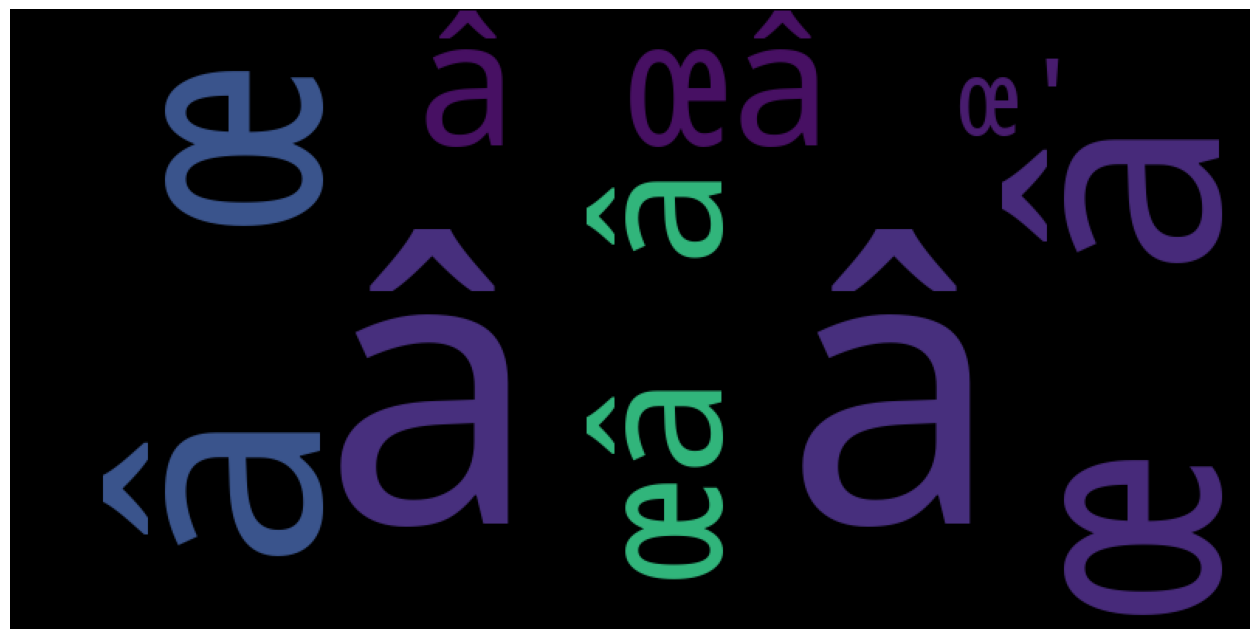

In [28]:
wordcloud = WordCloud(
    width=800,
    height=400
).generate(' '.join(all_words))

plt.figure(figsize=(16,10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [29]:
corpus = train_df['clean_text'].head(1000)

vectorizer = CountVectorizer()

X_bow = vectorizer.fit_transform(corpus)
print(X_bow.shape)

(1000, 2)


In [30]:
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(corpus)

print(X_tfidf.shape)

(1000, 2)


In [31]:
sentences = train_df['lemmatized_tokens'].tolist()


sentences = sentences[:2000]

word2vec_model = Word2Vec(

    sentences,

    vector_size=50,

    window=5,

    min_count=2,

    workers=2
)

In [37]:
train_df['clean_text'].head()

,clean_text
1141313,", . . . , ...."
701730,". . . .\n\n , ..."
401788,", . . , 3 , . ..."
377057,", . . \n\n, ..."
1629778,", . .\n\n . . .\n\n ..."


In [38]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')

sample = 'Once Upon a Time'

tokens = tokenizer.encode(sample)

print(tokens)

print(tokenizer.decode(tokens))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[7454, 14438, 257, 3862]
Once Upon a Time


In [39]:
story_generator = pipeline(
    'text-generation',
    model='gpt2'
)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [40]:
story = story_generator(

    "Once upon a time in a magical kingdom",

    max_length=100,

    num_return_sequences=1
)

print(story[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time in a magical kingdom, a girl who came from out of nowhere was transformed into a dragon. In the past, she had been made into a dragon by the king's blessing and thus had the ability to fly. It was only when she was caught by the king's spell that she was transformed into a dragon.

Seeing this, I was puzzled.

"What is the origin of this magic?"

"It's called the 'Dragon's Blessing'. It's a blessing that makes a child's soul shine. The most powerful dragon can be used to power a dragon so powerful that his body is also transformed into a dragon. The dragon's soul is transformed into the dragon's spirit. The soul's soul is turned into a dragon's body, and that's what the dragon's body is made of. The dragon's body is also transformed into a dragon's body. After the dragon's body is transformed, it is brought to life in a special form. The dragon's body comes back, and that's what its body is made of. The body is then transformed into a dragon's body. The dragon's spirit

In [41]:
genre = "Fantasy"

prompt = f"""

Write a {genre} story
about a dragon and hidden treasure."""

story = story_generator(
    prompt,
    max_length=100,
    temperature=0.8
)

print(story[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a Fantasy story
about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasure.

Write a fantasy story about a dragon and hidden treasu

In [42]:
prompt = """

Create a fantasy character.

Name:
Personality:
Abilities:
Backstory:

"""

character = story_generator(

    prompt,

    max_length=150
)

print(character[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Create a fantasy character.

Name:
Personality:
Abilities:
Backstory:


Fantasy character's name is usually used as a reference to the character of a fantasy series. It is usually used to refer to the character of an MMORPG.

Name:

Personality:

Alignment:

Alignment:

Appearance:

Personality:

Abilities:


Backstory:


Fantasy character's name is usually used as a reference to the character of a fantasy series. It is usually used to refer to the character of an MMORPG.

Name:

Personality:

Alignment:

Alignment:

Appearance:

Personality:

Abilities:


Backstory:


Fantasy character's name is usually used as a reference to the character of a fantasy series. It is usually used to refer to the character of an MMORPG.

Name:

Personality:

Alignment:

Alignment:

Appearance:

Personality:

Abilities:


Backstory:


Fantasy character's name is usually used as a reference to the character of a fantasy series. It is usually used to refer to the character of an MMORPG.

Name


In [43]:
prompt = """

The old castle door slowly opened,
and suddenly a strange whisper came from inside.

"""

continuation = story_generator(

    prompt,

    max_length=150,

    temperature=0.9
)

print(continuation[0]['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




The old castle door slowly opened,
and suddenly a strange whisper came from inside.


Shattered by light, the house stood tall with a stone ceiling and wall behind.

The old man's face was in sharp, dark red and pale to the touch,

the pale young man's face, the dark red lips, the dark purple skin,

the dark red eyes, the thin white hair and the thin thin red eyebrows,

the sharp white teeth and sharp grey teeth, the young man's cheeks were even more red.

His face was very pale and his face was rather pale,

his face had a cold, icy cold, cold face, and

his face had a very cold, cold, cold body,

his face had a very cold, cold, cold heart,

it was all very cold, cold, cold, cold and cold and cold and cold and cold but

its face was pale, its head and ears were pale,

its body was pale, it had only one eye

its body had only one ear.

The white and large figure with his eyes and the face full of eyes,

shine on the land, the land with big and small and big and

yonder and all over i

In [44]:
story = story_generator(

    prompt,

    max_length=150,

    num_beams=5,

    early_stopping=True
)

print(story[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_beams', 'early_stopping'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




The old castle door slowly opened,
and suddenly a strange whisper came from inside.


"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"

"What is it?"

"It's a door!"




In [45]:
stories = story_generator(

    prompt,

    max_length=120,

    num_return_sequences=3
)

for i, story in enumerate(stories):

    print(f"Story {i+1}")

    print(story['generated_text'])

    print("-"*50)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Story 1


The old castle door slowly opened,
and suddenly a strange whisper came from inside.


The castle door slowly opened...

It was a child-sized boy that was curled up on his back in a ball on the ground.

The child was a boy named A-O.

The boy was very beautiful, and A-O was quite handsome.

The boy was well-behaved, and A-O was not afraid to smile.


The boy...was A-O.


"Oh!"

The boy's face was so beautiful, that A-O couldn't even look at it.

The boy stared at A-O for a long time, and A-O only nodded his head.


The boy started crying, and slowly began to cry.


"Oh, I'm so glad I found you. Oh, please, please, please..."

"Oh, A-O!!!"

The boy's face was filled with tears.


The boy started crying again... The boy started crying again...


"Oh, A-O! My heart's pounding!!!"

The boy's face was filled with tears...


"Oh, A-O! My heart's pounding!!!"

The boy's face was filled with
--------------------------------------------------
Story 2


The old castle door slowly opened

In [46]:
stories = story_generator(

    prompt,

    max_length=120,

    num_return_sequences=3
)

for i, story in enumerate(stories):

    print(f"Story {i+1}")

    print(story['generated_text'])

    print("-"*50)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Story 1


The old castle door slowly opened,
and suddenly a strange whisper came from inside.


"I'm back!"

"What?"

"Ah, sorry, so I'm back."

"Ah, I am not back. My name is Shizuru, and I'm the son of a noble woman. I got married and have three children, but I can't go to the guild to fight anymore, so I've been living in a castle for awhile. I'm going to get married tomorrow, and I'm going to see my daughter soon. I'm going to a hospital for a few days, but I'm going to have to go back to the guild. I'm going to live with my grandparents, and my brother, who has a large family. So I'll stay behind to keep my family at ease. But I can't go back to the guild because I forgot to take care of my family. I'm not going back to the guild because I'm afraid of the guild. So, what is this? What's wrong with you?"

"How can you say that?"

"What is this? This is wrong with you, my dear Shizuru. I've been to the guild for a week, and I've never seen anyone so ugly. I'm not going back because 

In [47]:
story_generator.model.save_pretrained("story_model")

tokenizer.save_pretrained("story_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('story_model/tokenizer_config.json', 'story_model/tokenizer.json')

In [48]:
story_generator.model.save_pretrained("story_model")

tokenizer.save_pretrained("story_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('story_model/tokenizer_config.json', 'story_model/tokenizer.json')

In [49]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 49.3 MB/s eta 0:00:00


In [50]:
%%writefile app.py

import streamlit as st

from transformers import pipeline

story_generator = pipeline(
    "text-generation",
    model="gpt2"
)

st.title("AI Story Generator")

genre = st.selectbox(
    "Select Genre",
    ["Fantasy", "Horror", "Sci-Fi"]
)

prompt = st.text_area("Enter Prompt")

if st.button("Generate"):

    final_prompt = f"{genre} story: {prompt}"

    story = story_generator(
        final_prompt,
        max_length=150
    )

    st.write(story[0]['generated_text'])

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧

⠇⠏⠋⠙⠹⠸⠼Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-31 02:14:20.809 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.133.135.253:8501



In [ ]:
y
